In [1]:
# average function

"""Aggregate LC/FC/ER across seeds at fixed f.

Approach C with extended metrics: also tracks LC*FC and LC/FC alongside
LC and FC. Per-seed cross-dataset correlations -> mean ± std across seeds.
"""
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr

LC_FC_BASE = Path("/extdata1/donghwan/freeshap/vinfo/freeshap_res/label_concentration")
DEFAULT_SEEDS = (2024, 2025, 2026)
METRICS = ["LC", "FC", "LC_FC_prod", "LC_FC_ratio"]
METRIC_LABELS = {
    "LC": "LC",
    "FC": "FC",
    "LC_FC_prod": "LC·FC",
    "LC_FC_ratio": "LC/FC",
}


def _load_seed_data(seed, f_percent):
    nb_path = LC_FC_BASE / f"seed{seed}" / f"lc_fc_analysis_f{f_percent}.ipynb"
    if not nb_path.exists():
        raise FileNotFoundError(nb_path)
    nb = json.load(open(nb_path))
    ns = {}
    for cell in nb["cells"]:
        if cell["cell_type"] != "code":
            continue
        src = "".join(cell["source"])
        if "matplotlib" in src or "plt.subplots" in src:
            break
        exec(src, ns)
    return {
        "NUM_TRAIN_DP": ns["NUM_TRAIN_DP"],
        "DATASETS": list(ns["DATASETS"]),
        "R_VALUES": list(ns["R_VALUES"]),
        "ACC_BASE": ns["ACC_BASE"],
        "ACC_INV": ns[f"ACC_INV_F{f_percent}"],
        "PER_RANK": ns["PER_RANK"],
    }


def per_seed_dataframes(f_percent, seeds=DEFAULT_SEEDS):
    dfs = []
    for s in seeds:
        d = _load_seed_data(s, f_percent)
        eigen_key = f"acc_eigen_f{f_percent}"
        rows = []
        for ds in d["DATASETS"]:
            ab, ai = d["ACC_BASE"][ds], d["ACC_INV"][ds]
            denom = ai - ab
            for r in d["R_VALUES"]:
                ent = d["PER_RANK"][ds][r]
                ae = ent[eigen_key]
                ER = (ae - ab) / denom if denom != 0 else float("nan")
                lc, fc = ent["LC"], ent["FC"]
                rows.append({
                    "seed": s, "dataset": ds, "num_train_dp": d["NUM_TRAIN_DP"][ds],
                    "r": r, "acc_base": ab, "acc_inv": ai, "acc_eigen": ae,
                    "LC": lc, "FC": fc,
                    "LC_FC_prod":  lc * fc,
                    "LC_FC_ratio": (lc / fc) if fc != 0 else float("nan"),
                    "ER": ER,
                })
        dfs.append(pd.DataFrame(rows))
    return dfs


def per_seed_correlations(dfs):
    rows = []
    for df in dfs:
        seed = int(df["seed"].iloc[0])
        for r in sorted(df["r"].unique()):
            sub = df[df["r"] == r]
            row = {"seed": seed, "r": r}
            for col in METRICS:
                p, _ = pearsonr(sub["ER"], sub[col])
                s, _ = spearmanr(sub["ER"], sub[col])
                row[f"pearson_{col}"]  = p
                row[f"spearman_{col}"] = s
            rows.append(row)
    return pd.DataFrame(rows)


def analyze_avg(f_percent, seeds=DEFAULT_SEEDS, save_prefix=None):
    """Per-seed -> mean ± std. Tracks LC, FC, LC*FC, LC/FC."""
    dfs = per_seed_dataframes(f_percent, seeds)
    DATASETS = list(dfs[0]["dataset"].unique())
    R_VALUES = sorted(dfs[0]["r"].unique())
    NUM_TRAIN_DP = dict(zip(dfs[0]["dataset"], dfs[0]["num_train_dp"]))
    n_seeds = len(seeds)

    all_df = pd.concat(dfs, ignore_index=True)

    # Per-(dataset, r) means/stds
    agg_dr = (all_df.groupby(["dataset", "r"])
              .agg(LC_mean=("LC", "mean"),       LC_std=("LC", "std"),
                   FC_mean=("FC", "mean"),       FC_std=("FC", "std"),
                   LCFC_prod_mean=("LC_FC_prod", "mean"),  LCFC_prod_std=("LC_FC_prod", "std"),
                   LCFC_ratio_mean=("LC_FC_ratio", "mean"), LCFC_ratio_std=("LC_FC_ratio", "std"),
                   ER_mean=("ER", "mean"),       ER_std=("ER", "std"))
              .reset_index())

    # Per-seed correlations -> aggregate
    corr_seed = per_seed_correlations(dfs)
    agg_kwargs = {}
    for col in METRICS:
        for stat in ["pearson", "spearman"]:
            agg_kwargs[f"{stat}_{col}_mean"] = (f"{stat}_{col}", "mean")
            agg_kwargs[f"{stat}_{col}_std"]  = (f"{stat}_{col}", "std")
    corr_agg = corr_seed.groupby("r").agg(**agg_kwargs).reset_index()

    # ----- Tables -----
    print("=" * 80)
    print(f"f = {f_percent}% | per-(dataset, r) ER mean ± std across {n_seeds} seeds")
    print("=" * 80)
    print("\n[ER mean]")
    print(agg_dr.pivot(index="dataset", columns="r", values="ER_mean").reindex(DATASETS).round(4).to_string())
    print("\n[ER std]")
    print(agg_dr.pivot(index="dataset", columns="r", values="ER_std").reindex(DATASETS).round(4).to_string())

    print("\n" + "=" * 80)
    print(f"Per-seed correlations at f={f_percent}% (one row per seed)")
    print("=" * 80)
    cols = ["seed", "r"] + [f"pearson_{c}" for c in METRICS] + [f"spearman_{c}" for c in METRICS]
    print(corr_seed[cols].round(3).to_string(index=False))

    print("\n" + "=" * 80)
    print(f"Cross-dataset correlation: mean ± std across {n_seeds} seeds")
    print("=" * 80)
    rs_label = ", ".join(f"r={r}%" for r in R_VALUES)
    for stat in ["pearson", "spearman"]:
        print(f"\n  -- {stat.title()} --   [{rs_label}]")
        for col in METRICS:
            means = corr_agg[f"{stat}_{col}_mean"].values
            stds  = corr_agg[f"{stat}_{col}_std"].fillna(0).values
            cells = "  ".join(f"{m:+.3f}±{s:.3f}" for m, s in zip(means, stds))
            print(f"  {METRIC_LABELS[col]:>8s}: {cells}")

    # ----- 4-panel figure -----
    fig1, axes = plt.subplots(2, 2, figsize=(13, 9))
    for col_pair, ax, ylabel in [("LC", axes[0, 0], "LC(r)"),
                                  ("FC", axes[0, 1], "FC(r)"),
                                  ("ER", axes[1, 0], f"ER(r, f={f_percent}%)")]:
        for ds in DATASETS:
            sub = agg_dr[agg_dr["dataset"] == ds].sort_values("r")
            m = sub[f"{col_pair}_mean"].values
            s = sub[f"{col_pair}_std"].fillna(0).values
            line, = ax.plot(sub["r"], m, marker="o",
                            label=f"{ds} (n={NUM_TRAIN_DP[ds]})")
            ax.fill_between(sub["r"], m - s, m + s,
                            color=line.get_color(), alpha=0.12, linewidth=0)
        ax.set_xlabel("rank r (%)"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} vs r (mean ± std, {n_seeds} seeds, f={f_percent}%)")
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
        if col_pair == "ER":
            ax.axhline(1, color="k", lw=0.8, ls="--")

    # Correlation panel: Pearson for all 4 metrics (LC, FC, LC*FC, LC/FC)
    ax = axes[1, 1]
    panel_specs = [
        ("LC",          "o", "-",  "tab:blue"),
        ("FC",          "s", "-",  "tab:orange"),
        ("LC_FC_prod",  "^", "-",  "tab:green"),
        ("LC_FC_ratio", "v", "-",  "tab:red"),
    ]
    for col, mk, ls, c in panel_specs:
        m = corr_agg[f"pearson_{col}_mean"].values
        s = corr_agg[f"pearson_{col}_std"].fillna(0).values
        ax.errorbar(corr_agg["r"], m, yerr=s, marker=mk, ls=ls, color=c,
                    label=f"Pearson(ER, {METRIC_LABELS[col]})", capsize=3)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("rank r (%)"); ax.set_ylabel("correlation")
    ax.set_title(f"Cross-dataset Pearson(ER, ·) (mean ± std, {n_seeds} seeds, f={f_percent}%)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

    plt.tight_layout()
    if save_prefix:
        fig1.savefig(f"{save_prefix}_panel_f{f_percent}.pdf", bbox_inches="tight")
        fig1.savefig(f"{save_prefix}_panel_f{f_percent}.png", bbox_inches="tight", dpi=200)
    plt.show()

    # Scatter — ER vs each metric, mean over seeds
    fig2, axes = plt.subplots(2, 2, figsize=(12, 10))
    cmap = plt.get_cmap("viridis")
    colors = {r: cmap(i / max(1, len(R_VALUES) - 1)) for i, r in enumerate(R_VALUES)}
    markers = ["o", "s", "^", "v", "D", "P", "X"]
    marker_of = {ds: markers[i % len(markers)] for i, ds in enumerate(DATASETS)}

    scatter_specs = [
        ("LC",              axes[0, 0], "LC"),
        ("FC",              axes[0, 1], "FC"),
        ("LCFC_prod",       axes[1, 0], "LC·FC"),
        ("LCFC_ratio",      axes[1, 1], "LC/FC"),
    ]
    for xcol, ax, xlabel in scatter_specs:
        for r in R_VALUES:
            sub = agg_dr[agg_dr["r"] == r]
            for _, row in sub.iterrows():
                ax.scatter(row[f"{xcol}_mean"], row["ER_mean"],
                           color=colors[r], marker=marker_of[row["dataset"]],
                           s=60, edgecolor="k", linewidth=0.4)
        ax.set_xlabel(xlabel); ax.set_ylabel("ER")
        ax.set_title(f"ER vs {xlabel} (mean over seeds, f={f_percent}%)")
        ax.grid(alpha=0.3)
        ax.axhline(1, color="k", lw=0.8, ls="--")

    r_handles  = [Line2D([0], [0], marker="o", color=colors[r], lw=0,
                         markersize=8, label=f"r={r}%") for r in R_VALUES]
    ds_handles = [Line2D([0], [0], marker=marker_of[ds], color="gray", lw=0,
                         markersize=8, label=ds) for ds in DATASETS]
    axes[0, 0].legend(handles=r_handles,  loc="best", fontsize=7, title="rank")
    axes[0, 1].legend(handles=ds_handles, loc="best", fontsize=7, title="dataset")
    plt.tight_layout()
    if save_prefix:
        fig2.savefig(f"{save_prefix}_scatter_f{f_percent}.pdf", bbox_inches="tight")
        fig2.savefig(f"{save_prefix}_scatter_f{f_percent}.png", bbox_inches="tight", dpi=200)
    plt.show()

    return agg_dr, corr_seed, corr_agg


f = 20% | per-(dataset, r) ER mean ± std across 3 seeds

[ER mean]
r            1       5       10      15      20      25      30
dataset                                                        
sst2     0.9572  1.0200  1.0342  1.0387  1.0521  1.0658  1.0663
qqp      0.5509  0.7325  0.8778  0.8520  0.9099  0.9002  0.8841
mnli     0.7023  0.8714  0.9598  0.9721  0.9276  0.9878  0.9935
ag_news  0.9628  0.9809  0.9895  0.9854  0.9955  0.9940  0.9890
mr       0.8713  0.9308  0.9486  0.9703  0.9868  1.0013  1.0003
mrpc     0.8249  0.9180  0.9263  0.9303  0.9665  0.9477  0.9836
rte      0.3480  0.7373  0.8091  0.8731  0.8828  0.9062  0.9155

[ER std]
r            1       5       10      15      20      25      30
dataset                                                        
sst2     0.0684  0.0713  0.0700  0.0523  0.0543  0.0423  0.0631
qqp      0.1021  0.0547  0.0258  0.0252  0.0389  0.0142  0.0172
mnli     0.0655  0.0077  0.0105  0.0620  0.0697  0.0245  0.0177
ag_news  0.0109  0.0201  0.

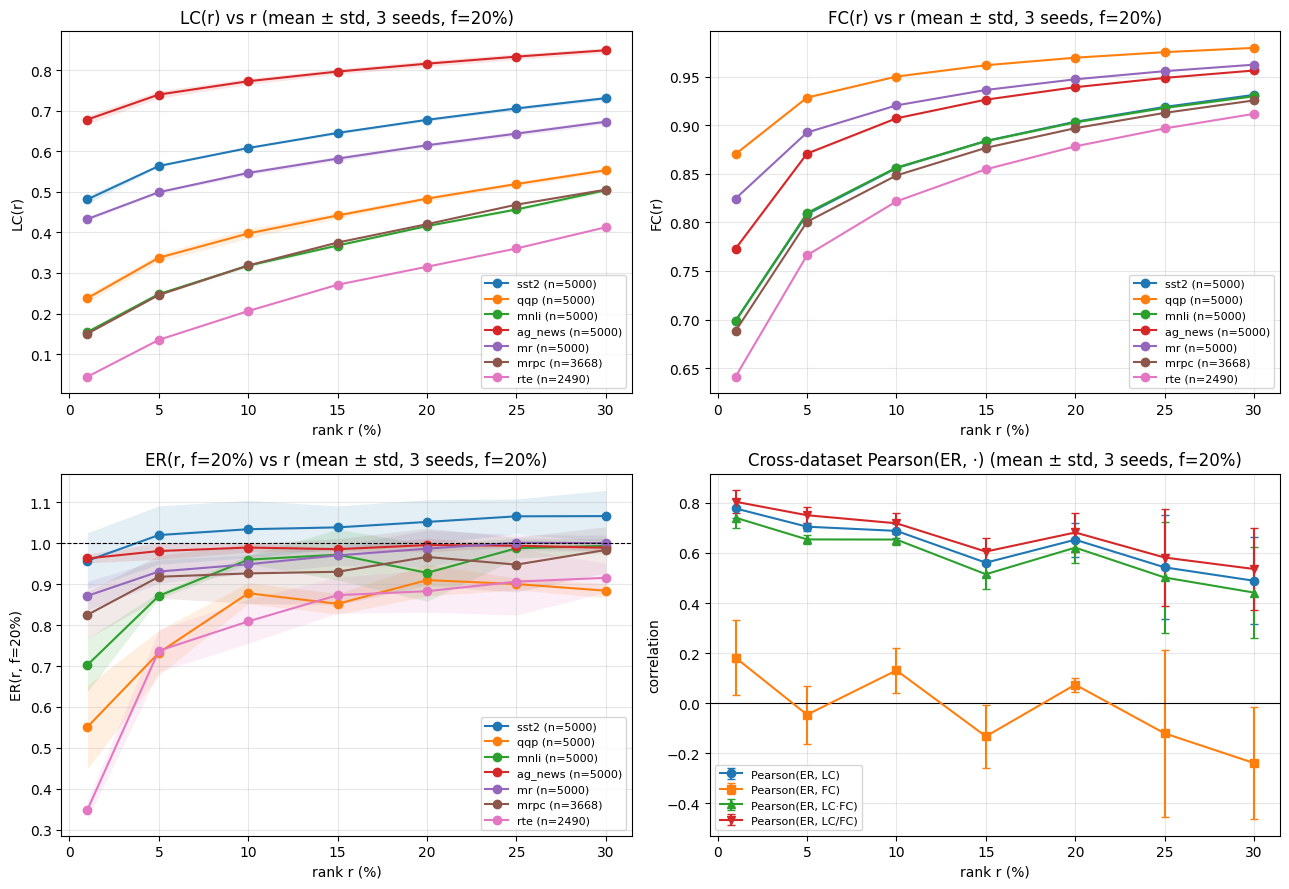

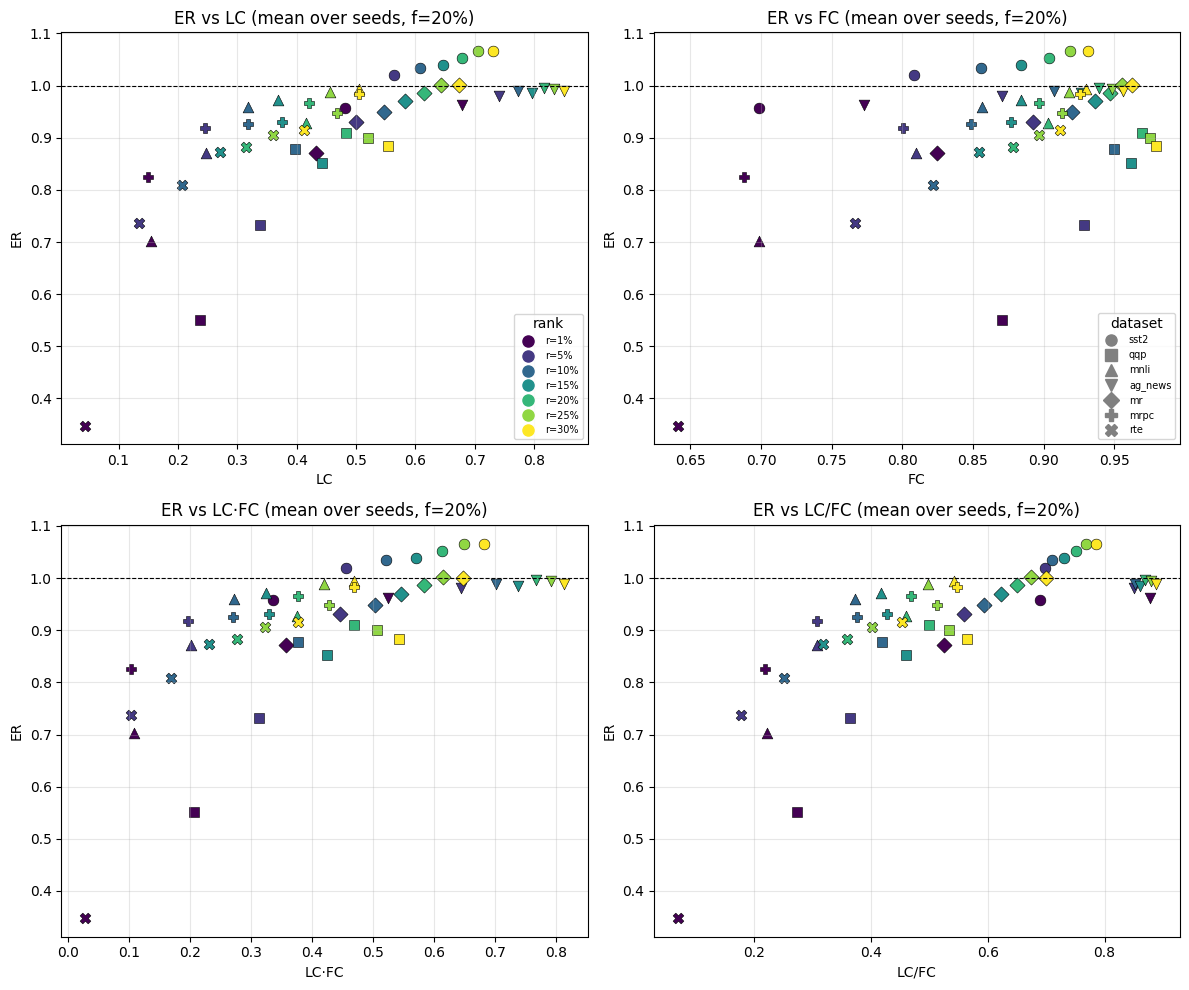

(                              dataset   r   LC_mean        LC_std   FC_mean   
 typing.Literal[<no_default>]                                                  
 0                             ag_news   1  0.678401  1.038258e-02  0.772931  \
 1                             ag_news   5  0.740105  8.685628e-03  0.870799   
 2                             ag_news  10  0.772946  7.470850e-03  0.907089   
 3                             ag_news  15  0.796818  6.536800e-03  0.926282   
 4                             ag_news  20  0.816269  7.376962e-03  0.939105   
 5                             ag_news  25  0.833622  7.128033e-03  0.948673   
 6                             ag_news  30  0.849357  6.109924e-03  0.956274   
 7                                mnli   1  0.154368  4.094792e-03  0.698495   
 8                                mnli   5  0.248028  3.618370e-03  0.809606   
 9                                mnli  10  0.318244  4.617413e-03  0.856345   
 10                               mnli  

In [2]:
# average f=20%
analyze_avg(20)


f = 20% | within-dataset correlation (sweep r per dataset)
  Each cell: mean ± std across 3 seeds

  -- Pearson(ER, ·) --
                          LC              FC
        sst2    +0.907±0.071    +0.933±0.049
         qqp    +0.885±0.042    +0.958±0.014
        mnli    +0.855±0.037    +0.933±0.037
     ag_news    +0.800±0.125    +0.853±0.098
          mr    +0.958±0.029    +0.966±0.014
        mrpc    +0.851±0.034    +0.896±0.078
         rte    +0.867±0.027    +0.961±0.020

  -- Spearman(ER, ·) --
                          LC              FC
        sst2    +0.821±0.189    +0.821±0.189
         qqp    +0.750±0.156    +0.750±0.156
        mnli    +0.785±0.086    +0.785±0.086
     ag_news    +0.628±0.282    +0.628±0.282
          mr    +0.937±0.073    +0.937±0.073
        mrpc    +0.754±0.122    +0.754±0.122
         rte    +0.902±0.105    +0.902±0.105


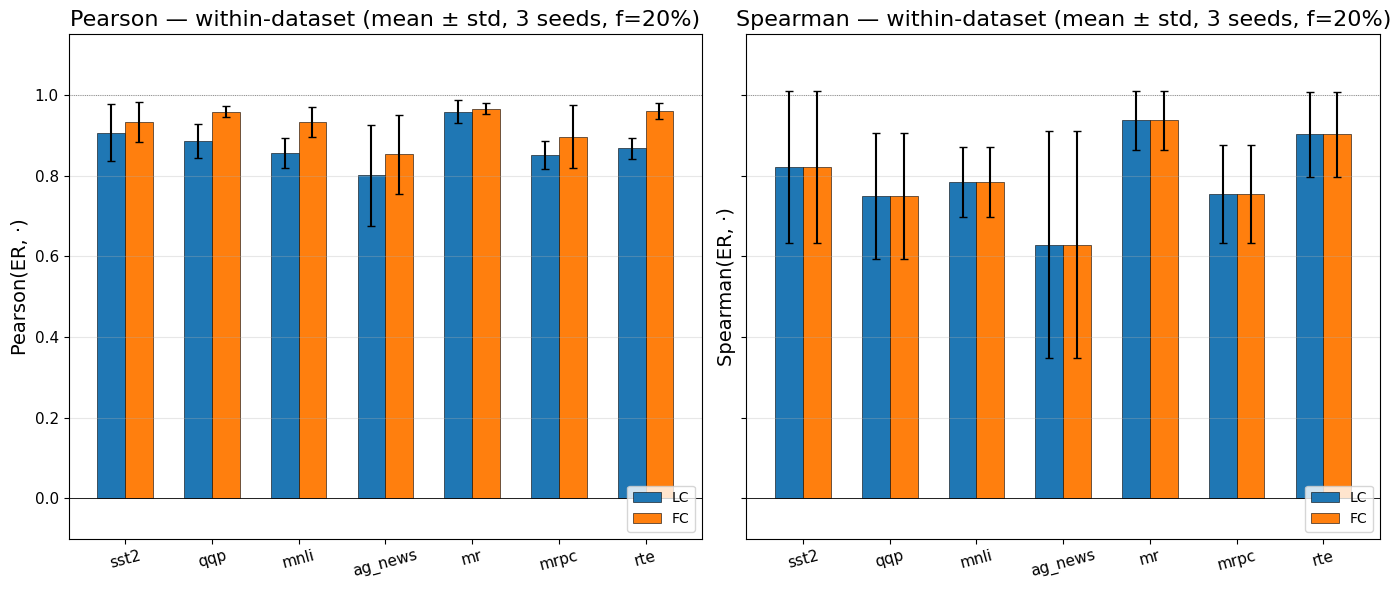

(    seed  dataset  pearson_LC  spearman_LC  pearson_FC  spearman_FC
 0   2024     sst2    0.870904     0.607143    0.939304     0.607143
 1   2024      qqp    0.903879     0.821429    0.971069     0.821429
 2   2024     mnli    0.872698     0.882919    0.936846     0.882919
 3   2024  ag_news    0.835588     0.828862    0.906383     0.828862
 4   2024       mr    0.980159     1.000000    0.950737     1.000000
 5   2024     mrpc    0.859547     0.666694    0.945311     0.666694
 6   2024      rte    0.838846     0.785714    0.938904     0.785714
 7   2025     sst2    0.988361     0.964286    0.978993     0.964286
 8   2025      qqp    0.837142     0.571429    0.943529     0.571429
 9   2025     mnli    0.813138     0.750000    0.894641     0.750000
 10  2025  ag_news    0.660871     0.306319    0.739951     0.306319
 11  2025       mr    0.925903     0.857143    0.967973     0.857143
 12  2025     mrpc    0.880001     0.892857    0.936308     0.892857
 13  2025      rte    0.870646    

In [3]:
# within-dataset correlations (sweep r per dataset, average across seeds)
# Trivially near +1 because LC, FC, ER are all monotone in r — included for verification.
# LC*FC and LC/FC excluded: in within-task they carry no extra info over LC, FC.

WITHIN_METRICS = ["LC", "FC"]


def within_dataset_correlations(dfs, metrics=WITHIN_METRICS):
    rows = []
    for df in dfs:
        seed = int(df["seed"].iloc[0])
        for ds in df["dataset"].unique():
            sub = df[df["dataset"] == ds].sort_values("r")
            row = {"seed": seed, "dataset": ds}
            for col in metrics:
                p, _ = pearsonr(sub["ER"], sub[col])
                s, _ = spearmanr(sub["ER"], sub[col])
                row[f"pearson_{col}"]  = p
                row[f"spearman_{col}"] = s
            rows.append(row)
    return pd.DataFrame(rows)


def analyze_within(f_percent, seeds=DEFAULT_SEEDS):
    dfs = per_seed_dataframes(f_percent, seeds)
    DATASETS = list(dfs[0]["dataset"].unique())
    n_seeds = len(seeds)
    within = within_dataset_correlations(dfs)

    agg_kwargs = {}
    for col in WITHIN_METRICS:
        for stat in ["pearson", "spearman"]:
            agg_kwargs[f"{stat}_{col}_mean"] = (f"{stat}_{col}", "mean")
            agg_kwargs[f"{stat}_{col}_std"]  = (f"{stat}_{col}", "std")
    agg = within.groupby("dataset").agg(**agg_kwargs).reindex(DATASETS).reset_index()

    print("=" * 72)
    print(f"f = {f_percent}% | within-dataset correlation (sweep r per dataset)")
    print(f"  Each cell: mean ± std across {n_seeds} seeds")
    print("=" * 72)
    for stat in ["pearson", "spearman"]:
        print(f"\n  -- {stat.title()}(ER, ·) --")
        header = "  " + " " * 10 + "".join(f"{c:>16s}" for c in WITHIN_METRICS)
        print(header)
        for _, row in agg.iterrows():
            cells = "".join(
                f"{row[f'{stat}_{c}_mean']:+.3f}±{row[f'{stat}_{c}_std']:.3f}".rjust(16)
                for c in WITHIN_METRICS
            )
            print(f"  {row['dataset']:>10s}{cells}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    bar_w = 0.32
    x = np.arange(len(DATASETS))
    metric_colors = {"LC": "tab:blue", "FC": "tab:orange"}

    for ax, stat in zip(axes, ["pearson", "spearman"]):
        for j, col in enumerate(WITHIN_METRICS):
            offset = (j - (len(WITHIN_METRICS) - 1) / 2) * bar_w
            heights = agg[f"{stat}_{col}_mean"].values
            errs    = agg[f"{stat}_{col}_std"].fillna(0).values
            ax.bar(x + offset, heights, bar_w, yerr=errs,
                   color=metric_colors[col], edgecolor="black", linewidth=0.4,
                   label=col, capsize=3)
        ax.axhline(1, color="k", lw=0.6, ls=":", alpha=0.5)
        ax.axhline(0, color="k", lw=0.6)
        ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=15)
        ax.set_ylabel(f"{stat.title()}(ER, ·)", fontsize=14)
        ax.set_title(f"{stat.title()} — within-dataset (mean ± std, {n_seeds} seeds, f={f_percent}%)", fontsize=16)
        ax.set_ylim(-0.1, 1.15)
        ax.tick_params(labelsize=11)
        ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=10, loc="lower right")
    plt.tight_layout(); plt.show()

    return within, agg


analyze_within(20)


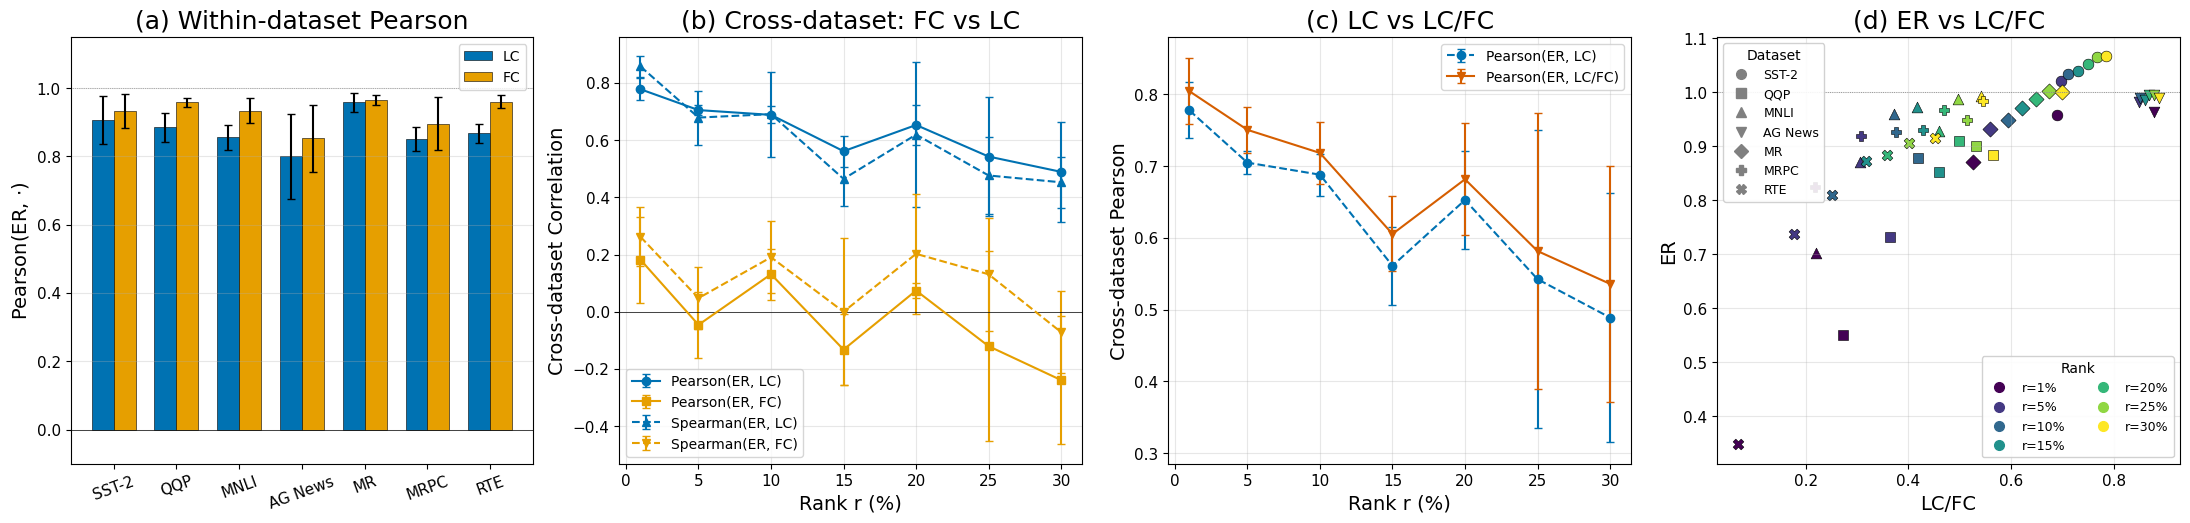

In [4]:
# Paper figure: 1x4 panel for f=20%
# (1,1) Within-dataset Pearson (LC, FC) bar
# (1,2) Cross-dataset Pearson + Spearman (LC, FC)
# (1,3) Cross-dataset Pearson (LC, LC/FC)
# (1,4) Scatter ER vs LC/FC (mean over seeds)

f_percent = 20
seeds = DEFAULT_SEEDS
dfs = per_seed_dataframes(f_percent, seeds)
DATASETS = list(dfs[0]["dataset"].unique())
R_VALUES = sorted(dfs[0]["r"].unique())
n_seeds = len(seeds)

DISPLAY_NAMES = {"sst2": "SST-2", "qqp": "QQP", "mnli": "MNLI",
                 "ag_news": "AG News", "mr": "MR", "mrpc": "MRPC", "rte": "RTE"}
LEGEND_ORDER = ["sst2", "qqp", "mnli", "ag_news", "mr", "mrpc", "rte"]

all_df = pd.concat(dfs, ignore_index=True)

agg_dr = (all_df.groupby(["dataset", "r"])
          .agg(LC_FC_ratio_mean=("LC_FC_ratio", "mean"),
               ER_mean=("ER", "mean"))
          .reset_index())

# Within-dataset (per dataset, sweep r)
within = within_dataset_correlations(dfs)
within_kwargs = {}
for col in ["LC", "FC"]:
    within_kwargs[f"pearson_{col}_mean"] = (f"pearson_{col}", "mean")
    within_kwargs[f"pearson_{col}_std"]  = (f"pearson_{col}", "std")
within_agg = within.groupby("dataset").agg(**within_kwargs).reindex(DATASETS).reset_index()

# Cross-dataset (per r, varying datasets)
corr_seed = per_seed_correlations(dfs)
cross_kwargs = {}
for col in ["LC", "FC", "LC_FC_ratio"]:
    for stat in ["pearson", "spearman"]:
        cross_kwargs[f"{stat}_{col}_mean"] = (f"{stat}_{col}", "mean")
        cross_kwargs[f"{stat}_{col}_std"]  = (f"{stat}_{col}", "std")
corr_agg = corr_seed.groupby("r").agg(**cross_kwargs).reset_index()

# === Figure ===
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

# --- (1,1) Within-dataset Pearson bar ---
ax = axes[0]
bar_w = 0.35
x = np.arange(len(DATASETS))
for j, col in enumerate(["LC", "FC"]):
    offset = (j - 0.5) * bar_w
    h = within_agg[f"pearson_{col}_mean"].values
    e = within_agg[f"pearson_{col}_std"].fillna(0).values
    ax.bar(x + offset, h, bar_w, yerr=e,
           color={"LC": "#0072B2", "FC": "#E69F00"}[col],
           edgecolor="black", linewidth=0.4, label=col, capsize=3)
ax.axhline(1, color="k", lw=0.5, ls=":", alpha=0.5)
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels([DISPLAY_NAMES.get(d, d) for d in DATASETS], rotation=20, fontsize=11)
ax.set_ylabel("Pearson(ER, $\cdot$)", fontsize=14)
ax.set_title(f"(a) Within-dataset Pearson", fontsize=18)
ax.set_ylim(-0.1, 1.15)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=10)

# --- (1,2) Cross-dataset Pearson + Spearman, LC vs FC ---
ax = axes[1]
specs_12 = [
    ("pearson_LC",  "Pearson(ER, LC)",  "o", "-",  "#0072B2"),
    ("pearson_FC",  "Pearson(ER, FC)",  "s", "-",  "#E69F00"),
    ("spearman_LC", "Spearman(ER, LC)", "^", "--", "#0072B2"),
    ("spearman_FC", "Spearman(ER, FC)", "v", "--", "#E69F00"),
]
for col, lbl, mk, ls, c in specs_12:
    m = corr_agg[f"{col}_mean"].values
    s = corr_agg[f"{col}_std"].fillna(0).values
    ax.errorbar(corr_agg["r"], m, yerr=s, marker=mk, ls=ls, color=c,
                label=lbl, capsize=3)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("Rank r (%)", fontsize=14); ax.set_ylabel("Cross-dataset Correlation", fontsize=14)
ax.set_title(f"(b) Cross-dataset: FC vs LC", fontsize=18)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3); ax.legend(fontsize=10, loc="best")

# --- (1,3) Cross-dataset Pearson, LC vs LC/FC ---
ax = axes[2]
specs_13 = [
    ("pearson_LC",          "Pearson(ER, LC)",    "o", "--", "#0072B2"),
    ("pearson_LC_FC_ratio", "Pearson(ER, LC/FC)", "v", "-",  "#D55E00"),
]
ymins, ymaxs = [], []
for col, lbl, mk, ls, c in specs_13:
    m = corr_agg[f"{col}_mean"].values
    s = corr_agg[f"{col}_std"].fillna(0).values
    ax.errorbar(corr_agg["r"], m, yerr=s, marker=mk, ls=ls, color=c,
                label=lbl, capsize=3)
    ymins.extend((m - s).tolist()); ymaxs.extend((m + s).tolist())
# Tight y-range so the LC vs LC/FC gap is visible
y_lo = min(ymins) - 0.03
y_hi = max(ymaxs) + 0.03
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel("Rank r (%)", fontsize=14); ax.set_ylabel("Cross-dataset Pearson", fontsize=14)
ax.set_title(f"(c) LC vs LC/FC", fontsize=18)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3); ax.legend(fontsize=10, loc="best")

# --- (1,4) Scatter ER vs LC/FC ---
ax = axes[3]
cmap = plt.get_cmap("viridis")
colors = {r: cmap(i / max(1, len(R_VALUES) - 1)) for i, r in enumerate(R_VALUES)}
markers = ["o", "s", "^", "v", "D", "P", "X"]
marker_of = {ds: markers[i % len(markers)] for i, ds in enumerate(DATASETS)}
for r in R_VALUES:
    sub = agg_dr[agg_dr["r"] == r]
    for _, row in sub.iterrows():
        ax.scatter(row["LC_FC_ratio_mean"], row["ER_mean"],
                   color=colors[r], marker=marker_of[row["dataset"]],
                   s=60, edgecolor="k", linewidth=0.4)
ax.axhline(1, color="gray", lw=0.6, ls=":")
ax.set_xlabel("LC/FC", fontsize=14); ax.set_ylabel("ER", fontsize=14)
ax.set_title(f"(d) ER vs LC/FC", fontsize=18)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)

# Two-part legend for scatter: ranks (color) and datasets (marker)
r_handles  = [Line2D([0], [0], marker="o", color=colors[r], lw=0,
                     markersize=7, label=f"r={r}%") for r in R_VALUES]
ds_handles = [Line2D([0], [0], marker=marker_of[ds], color="gray", lw=0,
                     markersize=7, label=DISPLAY_NAMES.get(ds, ds))
              for ds in LEGEND_ORDER if ds in marker_of]
leg1 = ax.legend(handles=r_handles, loc="lower right", fontsize=9,
                 title="Rank", ncol=2, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=ds_handles, loc="upper left", fontsize=9,
          title="Dataset", ncol=1, framealpha=0.9)

plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(f"lc_fc_panel_1x4_f{f_percent}.pdf", bbox_inches="tight")
fig.savefig(f"lc_fc_panel_1x4_f{f_percent}.png", bbox_inches="tight", dpi=200)
plt.show()


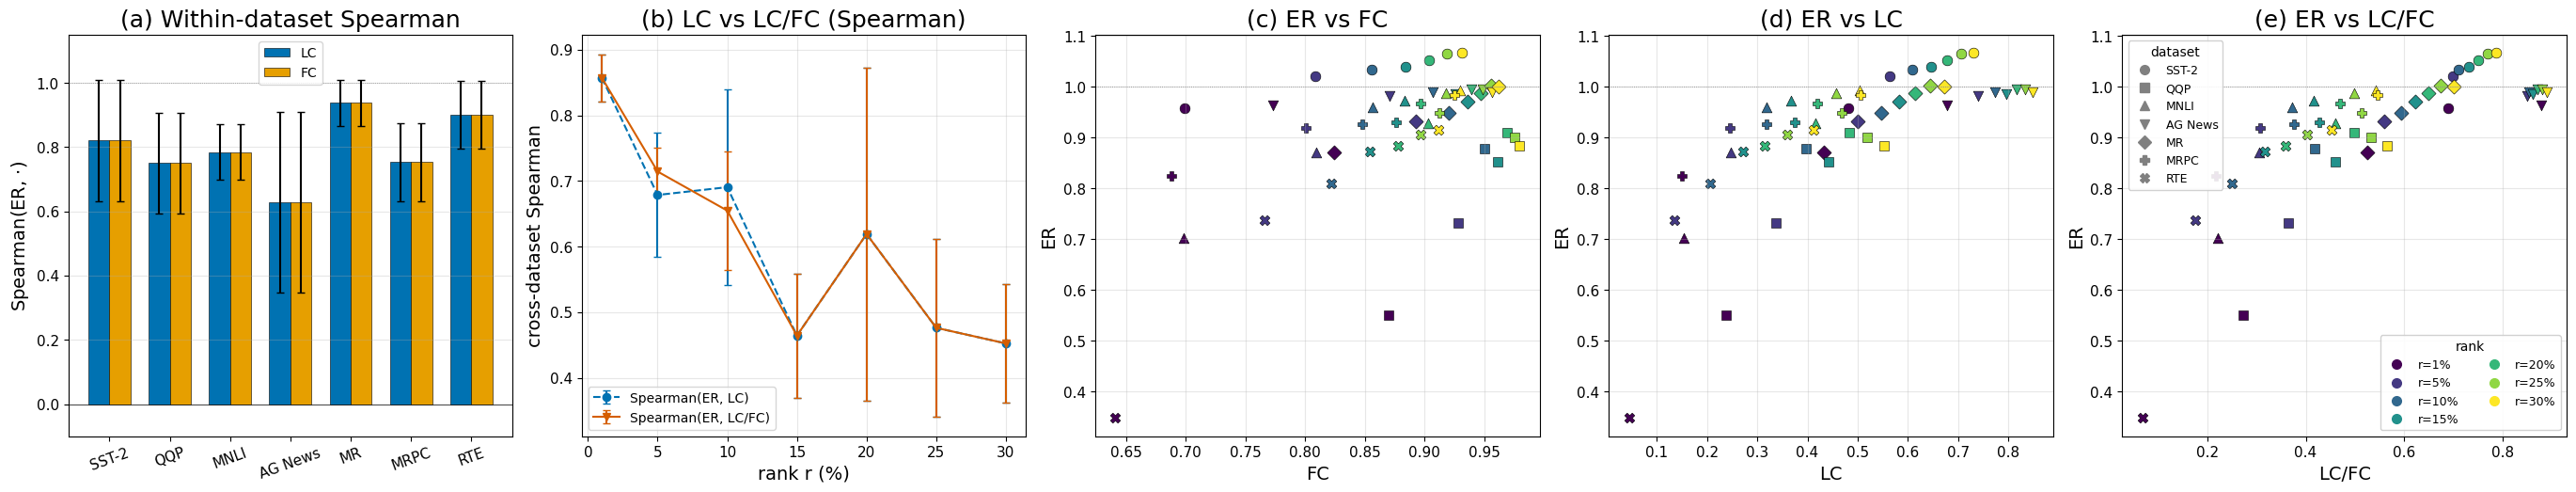

In [5]:
# Appendix figure: 1x5 supplementary panel for f=20%
#   (a) Within-dataset Spearman             — mirrors main (a) but Spearman
#   (b) Cross-dataset Spearman LC vs LC/FC  — mirrors main (c) but Spearman
#   (c) ER vs FC scatter                    — alternative x-axis vs main (d)
#   (d) ER vs LC scatter                    — alternative x-axis vs main (d)
#   (e) ER vs LC/FC scatter                 — same as main (d), shown for reference
# Style (fontsize, Okabe-Ito colors, viridis ranks) matches main paper fig.

f_percent = 20
seeds = DEFAULT_SEEDS
dfs = per_seed_dataframes(f_percent, seeds)
DATASETS = list(dfs[0]["dataset"].unique())
R_VALUES = sorted(dfs[0]["r"].unique())
n_seeds = len(seeds)

all_df = pd.concat(dfs, ignore_index=True)

# Per-(dataset, r) means including LC, FC, LC/FC
agg_dr_app = (all_df.groupby(["dataset", "r"])
              .agg(LC_mean=("LC", "mean"),
                   FC_mean=("FC", "mean"),
                   LC_FC_ratio_mean=("LC_FC_ratio", "mean"),
                   ER_mean=("ER", "mean"))
              .reset_index())

# Within-dataset Spearman (per seed -> mean ± std)
within_app = within_dataset_correlations(dfs)
within_kwargs = {}
for col in ["LC", "FC"]:
    within_kwargs[f"spearman_{col}_mean"] = (f"spearman_{col}", "mean")
    within_kwargs[f"spearman_{col}_std"]  = (f"spearman_{col}", "std")
within_agg_sp = (within_app.groupby("dataset").agg(**within_kwargs)
                 .reindex(DATASETS).reset_index())

# Cross-dataset Spearman (per seed -> mean ± std)
corr_seed_app = per_seed_correlations(dfs)
cross_kwargs = {}
for col in ["LC", "FC", "LC_FC_ratio"]:
    cross_kwargs[f"spearman_{col}_mean"] = (f"spearman_{col}", "mean")
    cross_kwargs[f"spearman_{col}_std"]  = (f"spearman_{col}", "std")
corr_agg_sp = corr_seed_app.groupby("r").agg(**cross_kwargs).reset_index()

# Style constants (Okabe-Ito + viridis, matching main fig)
LC_COLOR   = "#0072B2"
FC_COLOR   = "#E69F00"
LCFC_COLOR = "#D55E00"
cmap = plt.get_cmap("viridis")
rank_colors = {r: cmap(i / max(1, len(R_VALUES) - 1)) for i, r in enumerate(R_VALUES)}
markers = ["o", "s", "^", "v", "D", "P", "X"]
marker_of = {ds: markers[i % len(markers)] for i, ds in enumerate(DATASETS)}

# === Figure ===
fig, axes = plt.subplots(1, 5, figsize=(27.5, 5.5))

# --- (a) Within-dataset Spearman bar ---
ax = axes[0]
bar_w = 0.35
x = np.arange(len(DATASETS))
for j, col in enumerate(["LC", "FC"]):
    offset = (j - 0.5) * bar_w
    h = within_agg_sp[f"spearman_{col}_mean"].values
    e = within_agg_sp[f"spearman_{col}_std"].fillna(0).values
    ax.bar(x + offset, h, bar_w, yerr=e,
           color={"LC": LC_COLOR, "FC": FC_COLOR}[col],
           edgecolor="black", linewidth=0.4, label=col, capsize=3)
ax.axhline(1, color="k", lw=0.5, ls=":", alpha=0.5)
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels([DISPLAY_NAMES.get(d, d) for d in DATASETS],
                                     rotation=20, fontsize=11)
ax.set_ylabel("Spearman(ER, $\cdot$)", fontsize=14)
ax.set_title("(a) Within-dataset Spearman", fontsize=18)
ax.set_ylim(-0.1, 1.15)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=10)

# --- (b) Cross-dataset Spearman LC vs LC/FC ---
ax = axes[1]
specs_b = [
    ("spearman_LC",          "Spearman(ER, LC)",    "o", "--", LC_COLOR),
    ("spearman_LC_FC_ratio", "Spearman(ER, LC/FC)", "v", "-",  LCFC_COLOR),
]
ymins, ymaxs = [], []
for col, lbl, mk, ls, c in specs_b:
    m = corr_agg_sp[f"{col}_mean"].values
    s = corr_agg_sp[f"{col}_std"].fillna(0).values
    ax.errorbar(corr_agg_sp["r"], m, yerr=s, marker=mk, ls=ls, color=c,
                label=lbl, capsize=3)
    ymins.extend((m - s).tolist()); ymaxs.extend((m + s).tolist())
ax.set_ylim(min(ymins) - 0.03, max(ymaxs) + 0.03)
ax.set_xlabel("rank r (%)", fontsize=14)
ax.set_ylabel("cross-dataset Spearman", fontsize=14)
ax.set_title("(b) LC vs LC/FC (Spearman)", fontsize=18)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3); ax.legend(fontsize=10, loc="best")

# --- (c)/(d)/(e) ER vs {FC, LC, LC/FC} scatters ---
def _scatter_panel(ax, x_col, x_label, title):
    for r in R_VALUES:
        sub = agg_dr_app[agg_dr_app["r"] == r]
        for _, row in sub.iterrows():
            ax.scatter(row[x_col], row["ER_mean"],
                       color=rank_colors[r], marker=marker_of[row["dataset"]],
                       s=60, edgecolor="k", linewidth=0.4)
    ax.axhline(1, color="gray", lw=0.6, ls=":")
    ax.set_xlabel(x_label, fontsize=14); ax.set_ylabel("ER", fontsize=14)
    ax.set_title(title, fontsize=18)
    ax.tick_params(labelsize=11)
    ax.grid(alpha=0.3)

_scatter_panel(axes[2], "FC_mean",          "FC",    "(c) ER vs FC")
_scatter_panel(axes[3], "LC_mean",          "LC",    "(d) ER vs LC")
_scatter_panel(axes[4], "LC_FC_ratio_mean", "LC/FC", "(e) ER vs LC/FC")

# Two-part legend on the rightmost panel (matches main fig (d))
ax = axes[4]
r_handles  = [Line2D([0], [0], marker="o", color=rank_colors[r], lw=0,
                     markersize=7, label=f"r={r}%") for r in R_VALUES]
ds_handles = [Line2D([0], [0], marker=marker_of[ds], color="gray", lw=0,
                     markersize=7, label=DISPLAY_NAMES.get(ds, ds))
              for ds in LEGEND_ORDER if ds in marker_of]
leg1 = ax.legend(handles=r_handles, loc="lower right", fontsize=9,
                 title="rank", ncol=2, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=ds_handles, loc="upper left", fontsize=9,
          title="dataset", ncol=1, framealpha=0.9)

plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(f"lc_fc_appendix_1x5_f{f_percent}.pdf", bbox_inches="tight")
fig.savefig(f"lc_fc_appendix_1x5_f{f_percent}.png", bbox_inches="tight", dpi=200)
plt.show()
